# Galactic Diffuse Continuum

This tutorial demonstrates how to do a spectral fit of the Galactic diffuse continuum emission using an input GALPROP model in healpix format. 

In [1]:
import logging
import sys
import os

logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
# imports:
from cosipy import BinnedData
from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLExtendedSourceResponse
from cosipy.data_io import EmCDSBinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.ExtendedSourceResponse import ExtendedSourceResponse
from cosipy.threeml.custom_functions import GalpropHealpixModel
from cosipy.util import fetch_wasabi_file
from threeML import PointSource, Model, JointLikelihood, DataList, update_logging_level
from threeML.analysis_results import *
from astromodels import *
from astromodels.functions import GalPropTemplate_3D
import numpy as np
import matplotlib.pyplot as plt

18:17:02 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=13992381;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=13992382;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=13992388;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=13992389;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

18:17:03 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=13992396;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=13992397;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

18:17:03 INFO      Starting 3ML!                                                                     ]8;id=13992404;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=13992405;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=13992411;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=13992412;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

18:17:04 WARNING   ROOT minimizer not available                                                ]8;id=13992433;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=13992434;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1208\1208]8;;\

         WARNING   Multinest minimizer not available                                           ]8;id=13992440;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=13992441;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1218\1218]8;;\

         WARNING   PyGMO is not available                                                      ]8;id=13992447;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=13992448;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1228\1228]8;;\

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=13992454;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=13992455;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

18:17:05 WARNING   No fermitools installed                                              ]8;id=13992462;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=13992463;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

### Get the data

In [3]:
#path to download your data

data_path = Path("") # /path/to/files. Current dir by default

In [4]:
# ori file
fetch_wasabi_file('COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits', 
                  output = data_path / "DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits" , checksum = 'ca94ff1d7a73c1f41479aaf598807673')

A file named DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits already exists with the specified checksum (ca94ff1d7a73c1f41479aaf598807673). Skipping.


In [5]:
# background file
fetch_wasabi_file('COSI-SMEX/DC3/Data/Backgrounds/Ge/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz', 
                  output = data_path / "AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz" ,checksum = '191a451ee597fd2e4b1cf237fc72e6e2')

A file named AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz already exists with the specified checksum (191a451ee597fd2e4b1cf237fc72e6e2). Skipping.


In [6]:
# source file
fetch_wasabi_file('COSI-SMEX/DC3/Data/Sources/GalTotal_SA100_F98_3months_unbinned_data_filtered_with_SAAcut.fits.gz', 
                  output = data_path / "GalTotal_SA100_F98_3months_unbinned_data_filtered_with_SAAcut.fits.gz" ,checksum = '9fda5a7b15a90358abc2b886979f9fef')

A file named GalTotal_SA100_F98_3months_unbinned_data_filtered_with_SAAcut.fits.gz already exists with the specified checksum (9fda5a7b15a90358abc2b886979f9fef). Skipping.


In [7]:
# precomputed point source response
fetch_wasabi_file('COSI-SMEX/DC3/Data/Responses/extended_source_response/extended_source_response_continuum_merged.h5.gz', 
                  output = data_path / "extended_source_response_continuum_merged.h5.gz",unzip = True, checksum = '92ed7e22b1dafce6b57611d5cdb6cf70')

A file named extended_source_response_continuum_merged.h5 already exists with the specified checksum (92ed7e22b1dafce6b57611d5cdb6cf70). Skipping.


In [8]:
# GALPROP input model
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/galactic_diffuse_continuum/total_healpix_57_SA100_F98_example.gz', 
                  output = data_path / "total_healpix_57_SA100_F98_example.gz" ,checksum = '82cbeb9a86d86637f19f31c762f379fc')

A file named total_healpix_57_SA100_F98_example.gz already exists with the specified checksum (82cbeb9a86d86637f19f31c762f379fc). Skipping.


Input files:

In [9]:
ori_file = data_path / "DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
BG_file = data_path / "AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
src_file = data_path / "GalTotal_SA100_F98_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
psr_file = data_path / "extended_source_response_continuum_merged.h5"
galprop_model_file = data_path / "total_healpix_57_SA100_F98_example.gz"

### Make the dataset and bin
This step only needs to be run once. Afterwards, the files can be loaded directly using the cell below. 

In [10]:
# Bin galdiff:
galdiff = BinnedData("galdiff.yaml")
galdiff.get_binned_data(unbinned_data=src_file, output_name=data_path/"galdiff_binned_data")

# Bin background:
bg_tot = BinnedData("galdiff.yaml")
bg_tot.get_binned_data(unbinned_data=BG_file, output_name=data_path/ "albedo_photons_binned_data")

binning data...
Time unit: s
Em unit: keV
Phi unit: deg
PsiChi unit: None
binning data...
Time unit: s
Em unit: keV
Phi unit: deg
PsiChi unit: None


Load binned files:

In [11]:
#load signal
galdiff = BinnedData("galdiff.yaml")
galdiff.load_binned_data_from_hdf5(binned_data= data_path / "galdiff_binned_data.hdf5")

# Load background:
bg_tot = BinnedData("galdiff.yaml")
bg_tot.load_binned_data_from_hdf5(binned_data= data_path / "albedo_photons_binned_data.hdf5")

## Define GALPROP model
Below is how to define the custom GALPROP model. We will save the model to a yaml file so that it can be directly uploaded in the future (as shown at the bottom). 

In [12]:
# defining the model:
galprop_model = GalpropHealpixModel()
galprop_model.load_file(galprop_model_file)

# The spectrum is defined in the data cube, 
# and so we use a dummy model for defining an extended source in astromodels. 
# NB: This has no impact on the results - just make sure the parameter is fixed!
spectrum = Constant()
spectrum.k.value = 0.0
spectrum.k.free = False

src = ExtendedSource("galprop_source", spatial_shape=galprop_model, spectral_shape=spectrum)
model = Model(src)
model.save("galprop_model.yaml", overwrite=True)

# uncomment below to load saved model:
#model = load_model('galprop_model.yaml')

loading GALPROP model: total_healpix_57_SA100_F98_example.gz


## Setup and perform fit
Setup background parameter, extended source , orientation file and the LH fit

In [13]:
#open the orientation file
sc_orientation = SpacecraftHistory.open(ori_file)

#open the extended source response
dr = ExtendedSourceResponse.open(psr_file)



bkg_dist = {"background":bg_tot.binned_data.project('Em', 'Phi', 'PsiChi')}
               
# Workaround to avoid inf values. Out bkg should be smooth, but currently it's not.
# Reproduces results before refactoring. It's not _exactly_ the same, since this fudge value was 1e-12, and
# it was added to the expectation, not the normalized bkg
for bckfile in bkg_dist.keys() :
    bkg_dist[bckfile] += sys.float_info.min

#combine the data + the bck like we would get for real data
data = EmCDSBinnedData(galdiff.binned_data.project('Em', 'Phi', 'PsiChi') 
                       + bg_tot.binned_data.project('Em', 'Phi', 'PsiChi')
                    )
    
bkg = FreeNormBinnedBackground(bkg_dist,
                                   sc_history=sc_orientation,
                                   copy = False)

# Currently using the same NnuLambda, Ei and Pol axes as the underlying FullDetectorResponse,
# matching the behavior of v0.3. This is all the current BinnedInstrumentResponse can do.
# In principle, this can be decoupled, and a BinnedInstrumentResponseInterface implementation
# can provide the response for an arbitrary directions, Ei and Pol values.
    

esr = BinnedThreeMLExtendedSourceResponse(data = data,
                                          precomputed_psr = dr,
                                           
                                           polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                           )

##====


response = BinnedThreeMLModelFolding(data = data, extended_source_response = esr)

like_fun = PoissonLikelihood(data, response, bkg)

cosi = ThreeMLPluginInterface('cosi',
                                  like_fun,
                                  response,
                                  bkg)

cosi.bkg_parameter['background'] = Parameter("background",  # background parameter
                                      1,  # initial value of parameter
                                      unit = u.Hz, 
                                      min_value=0,  # minimum value of parameter
                                      max_value=10,  # maximum value of parameter
                                      delta=0.05,  # initial step used by fitting engine
                                      )

Instantiate the COSI 3ML plugin and perform the fit

In [14]:
# Optional: if you want to call get_log_like manually, then you also need to set the model manually
# 3ML does this internally during the fit though
cosi.set_model(model)

# Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit()



18:19:07 INFO      set the minimizer to minuit                                             ]8;id=13992470;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=13992471;file:///project/ckarwin/astro/chris/my_envs/cosipy_dev/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

... Reading Extended source response ...
--> done (source name : galprop_source)
Interpolating GALPROP map...
Integrating intensity over energy bins...


Best fit values:

,result,unit
parameter,,
galprop_source.GalpropHealpixModel.K,(7.721 +/- 0.008) x 10^-1,
background,4.5842 +/- 0.0013,Hz


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-171655715.58496818
total,-171655715.58496818


Values of statistical measures:

,statistical measures
AIC,-343311427.16988426
BIC,-343311406.47479194


(                                         value  negative_error  \
 galprop_source.GalpropHealpixModel.K  0.772051       -0.000816   
 background                            4.584189       -0.001326   
 
                                       positive_error     error unit  
 galprop_source.GalpropHealpixModel.K        0.000825  0.000821       
 background                                  0.001327  0.001326   Hz  ,
           -log(likelihood)
 cosi   -171655715.58496818
 total  -171655715.58496818)

In [15]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["galprop_source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["galprop_source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["galprop_source"])

Best fit values:

,result,unit
parameter,,
galprop_source.GalpropHealpixModel.K,(7.721 +/- 0.008) x 10^-1,
background,4.5842 +/- 0.0013,Hz


Correlation matrix:

1.00,-0.72
-0.72,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-171655715.58496818
total,-171655715.58496818


Values of statistical measures:

,statistical measures
AIC,-343311427.16988426
BIC,-343311406.47479194


None
  * galprop_source (extended source):
    * shape:
      * K:
        * value: 0.7720511839374528
        * desc: Normalization factor (unitless)
        * min_value: 0.0
        * max_value: 1000.0
        * unit: ''
        * is_normalization: true
    * spectrum:
      * main:
        * Constant:
          * k:
            * value: 0.0
            * desc: Constant value
            * min_value: null
            * max_value: null
            * unit: keV-1 s-1 cm-2
            * is_normalization: false
        * polarization: {}



## Make plots

Compare best-fit to injected source:


galdiff expected counts:
[7.75333266e+05 1.89566185e+06 1.76323417e+06 1.10662516e+06
 6.56070452e+05 3.87738180e+05 2.35773700e+05 9.77338299e+04
 2.13603721e+04 1.03920532e+03]



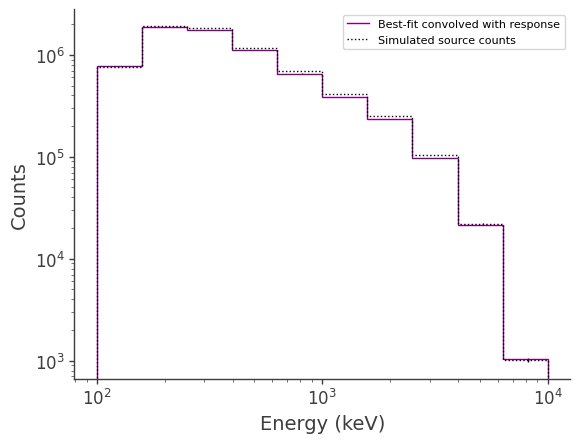

In [16]:
#[magic commented out by run_tutorials.py] %matplotlib inline
# Get expected counts from likelihood scan (i.e. best-fit convolved with response):
total_expectation = response.expectation(data)
print()
print("galdiff expected counts:")
print(total_expectation.project('Em').todense().contents)
print()

# Plot:
fig,ax = plt.subplots()

binned_energy_edges = galdiff.binned_data.axes['Em'].edges.value
binned_energy = galdiff.binned_data.axes['Em'].centers.value

ax.stairs(total_expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best-fit convolved with response")
ax.errorbar(binned_energy, total_expectation.project('Em').todense().contents, yerr=np.sqrt(total_expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(galdiff.binned_data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Simulated source counts")
ax.errorbar(binned_energy, galdiff.binned_data.project('Em').todense().contents, yerr=np.sqrt(galdiff.binned_data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")
plt.yscale('log')
plt.xscale('log')
ax.legend()
plt.savefig("injected_model_comparison.pdf")
plt.show()
plt.close()

percent difference: 

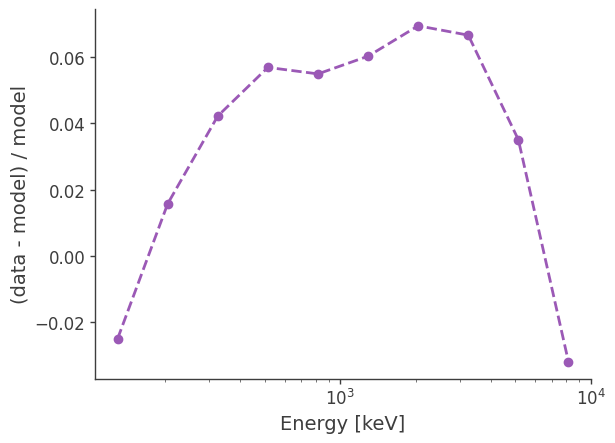

In [17]:
diff = (galdiff.binned_data.project('Em').todense().contents - total_expectation.project('Em').todense().contents)/total_expectation.project('Em').todense().contents

plt.semilogx(binned_energy,diff,ls="--",marker="o")
plt.xlabel("Energy [keV]")
plt.ylabel("(data - model) / model")
plt.savefig("percent_diff.pdf")
plt.show()
plt.close()

Compare best-fit to injected for total counts:

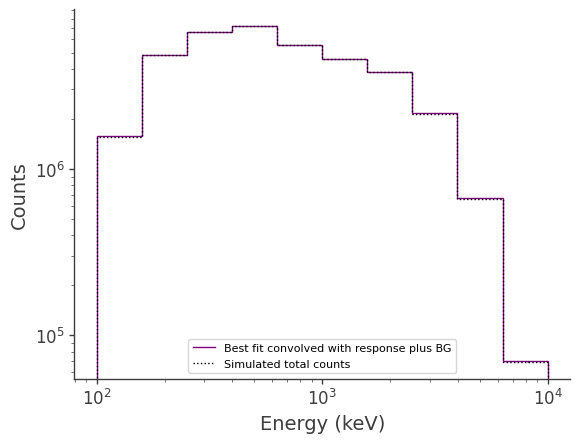

In [18]:
# Plot:
fig,ax = plt.subplots()

expectation_bkg = bkg.expectation(copy = True)
data_combined = galdiff.binned_data.project('Em').todense().contents+bg_tot.binned_data.project('Em').todense().contents


ax.stairs(total_expectation.project('Em').todense().contents \
        +(expectation_bkg.project('Em').todense().contents) \
        , binned_energy_edges, color='purple', label = "Best fit convolved with response plus BG")
ax.errorbar(binned_energy, total_expectation.project('Em').todense().contents \
        +(expectation_bkg.project('Em').todense().contents) \
        , yerr=np.sqrt(total_expectation.project('Em').todense().contents \
        +(expectation_bkg.project('Em').todense().contents)), \
        color='purple', linewidth=0, elinewidth=1)
ax.stairs(data_combined
          , binned_energy_edges, \
        color = 'black', ls = ":", label = "Simulated total counts")
ax.errorbar(binned_energy,data_combined, \
        yerr=np.sqrt(data_combined), color='black', linewidth=0, elinewidth=1)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()
plt.yscale('log')
plt.xscale('log')
plt.savefig("injected_total_comparison.pdf")
plt.show()
plt.close()

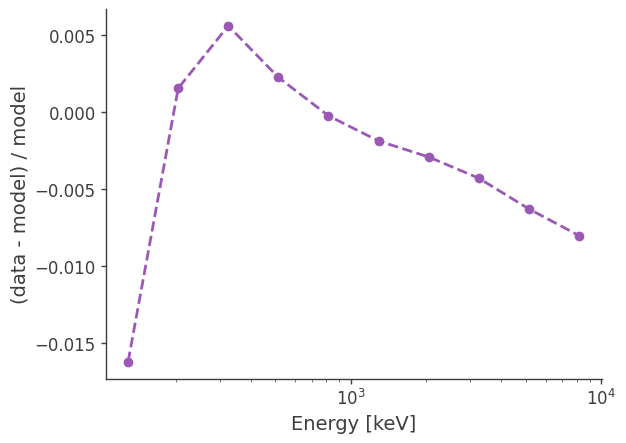

In [19]:


mod_tot = total_expectation.project('Em').todense().contents \
        +(expectation_bkg.project('Em').todense().contents)
diff = (data_combined - mod_tot)/mod_tot

plt.semilogx(binned_energy,diff,ls="--",marker="o")
plt.xlabel("Energy [keV]")
plt.ylabel("(data - model) / model")
plt.savefig("percent_diff.pdf")
plt.show()
plt.close()

Plot average intensity (averaged over full sky):

using nside=8 from user input in evaluate method
loading GALPROP model: total_healpix_57_SA100_F98_example.gz



WARNING SyntaxWarning: invalid escape sequence '\m'


WARNING SyntaxWarning: invalid escape sequence '\m'


WARNING SyntaxWarning: invalid escape sequence '\m'



Interpolating GALPROP map...
intensity error:
[6.45724583e-07 6.82695943e-07 7.12059817e-07 7.51876701e-07
 7.94740958e-07 8.67522322e-07 9.42967615e-07 1.05490452e-06
 1.16255292e-06 1.31519147e-06]


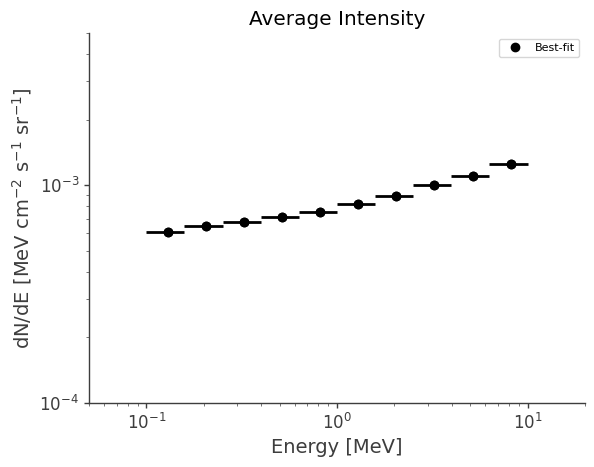

In [20]:
# Get parameter error manually:
K = results.optimized_model["galprop_source"].parameters["galprop_source.GalpropHealpixModel.K"].value
Kerr = K - results.get_variates('galprop_source.GalpropHealpixModel.K').equal_tail_interval()[0]

# We will pass the response nside in order to use the same spatial sampling as the fit:
nside = 8

# We will also use the same energy values as was used in the fit:
binned_energy = galdiff.binned_data.axes['Em'].centers.to(u.MeV).value
binned_energy_edges = galdiff.binned_data.axes['Em'].edges.to(u.MeV).value
energy_err = np.diff(binned_energy_edges)/2.0

# Below we will pass avg_int=True in order to get the average intensity. Otherwise, the function returns the total intensity by default.
intensity = results.optimized_model["galprop_source"].spatial_shape.get_total_spatial_integral(binned_energy, avg_int=True, nside=nside)
intensity = intensity.value

yerr = (Kerr/K)*(intensity)
yerr *= (binned_energy**2)
print("intensity error:")
print(yerr)

intensity *= (binned_energy**2)

fig,ax = plt.subplots()

ax.loglog(binned_energy, intensity, ls="", marker="o", color="black", label = "Best-fit")
ax.errorbar(binned_energy, intensity, xerr=energy_err, yerr=yerr, ls="", marker="o", color="black", label = "_nolabel_")

# Plot model specturm with galpy:
# This is optional and requires galpy package:
# https://github.com/ckarwin/galpy
#from galpy import GalMapsHeal
#instance = GalMapsHeal()
#instance.read_healpix_file("GALPROP_DC3/total_healpix_57_SA100_F98_example.gz")
#instance.make_spectrum()
#gal_energy = instance.energy
#gal_spec = instance.spectra_list
#ax.loglog(gal_energy, gal_spec, ls="-", marker="", color="red", label = "GALPROP model")

plt.ylabel("dN/dE [$\mathrm{MeV \ cm^{-2} \ s^{-1} \ sr^{-1}}$]")
plt.xlabel("Energy [MeV]")
plt.title("Average Intensity")
ax.legend()
plt.xlim(5e-2,20)
plt.ylim(1e-4,5e-3)
plt.savefig("intensity.pdf")
plt.show()
plt.close()

Below we plot the best-fit spectrum just for demonstration. Again, this is just a dummy model since the spectrum is contained in the 3D data cube. This has no impact on the fit.    


WARNING SyntaxWarning: invalid escape sequence '\m'


WARNING SyntaxWarning: invalid escape sequence '\m'


WARNING SyntaxWarning: invalid escape sequence '\m'



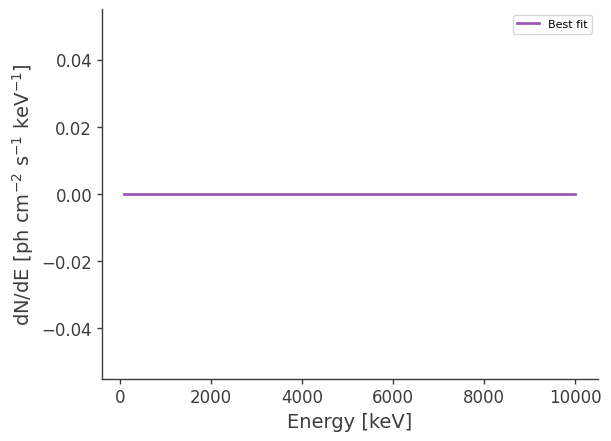

In [21]:
energy = np.linspace(100.,10000.,201)*u.keV
flux = results.optimized_model["galprop_source"].spectrum.main.shape(energy)

fig,ax = plt.subplots()

ax.plot(energy, flux, label = "Best fit")

plt.ylabel("dN/dE [$\mathrm{ph \ cm^{-2} \ s^{-1} \ keV^{-1}}$]", fontsize=14)
plt.xlabel("Energy [keV]", fontsize=14)
ax.legend()
plt.savefig("best_fit_model.pdf")
plt.show()
plt.close()